In [2]:
#/busr/bin/env python
from netCDF4 import Dataset
import modeltools.hycom
import abfile.abfile as abf
import numpy as np
from pathlib import Path
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

In [3]:
DATADIR = "/root/sigma2/betzy_projects_nn9481k/wakamatsut/bioran_v2/data/"

file_depth = f"{DATADIR}regional.depth.a"
file_grid = f"{DATADIR}regional.grid.a"

In [4]:
onemm=9.806

ab_grid = abf.ABFileGrid(file_grid,"r")
ab_dpth = abf.ABFileBathy(file_depth,"r",idm=ab_grid.idm,jdm=ab_grid.jdm)

plon=ab_grid.read_field("plon")
plat=ab_grid.read_field("plat")
target_lonlats=[plon,plat]

mdpth=ab_dpth.read_field('depth')
maskd=mdpth.data
maskd[maskd>1e29]=np.nan

print(plon.shape)
print(plat.shape)

(380, 400)
(380, 400)


In [5]:
archmfile = f"{DATADIR}archm.2016_247_12.a"

ab_archm = abf.ABFileArchv(archmfile,"r")

In [6]:
def plot_field(plon,plat,fld,list_extent,projection):
    figsize=(8,8)
    crs_latlon = ccrs.PlateCarree()
    ig, ax = plt.subplots(figsize=figsize, subplot_kw={'projection': projection})
    ax.set_extent(list_extent, crs=crs_latlon)
    ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    ax.add_feature(cfeature.COASTLINE, edgecolor='black',linewidth=0.5)
    ax.add_feature(cfeature.LAND, edgecolor='black', facecolor='palegoldenrod')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue',alpha=0.3)
    ax.pcolormesh(plon,plat,fld,cmap=cmap, shading='auto', transform=crs_latlon, label='SST')

In [7]:
cmap=plt.get_cmap("jet")

fieldname = "temp"
fieldlevel = 1

fld1 = ab_archm.read_field(fieldname,fieldlevel)
if "srfhgt" in fieldname:
    fld1= fld1/onemm

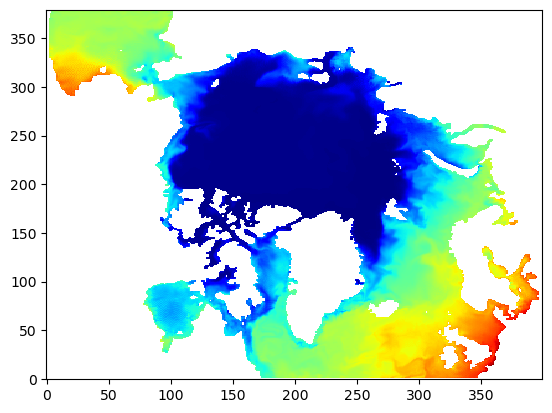

In [8]:
x,y=np.meshgrid(np.arange(plon.shape[1]),np.arange(plon.shape[0]))
figure, ax = plt.subplots()
P=plt.pcolormesh(x,y,fld1,cmap=cmap, shading='auto')

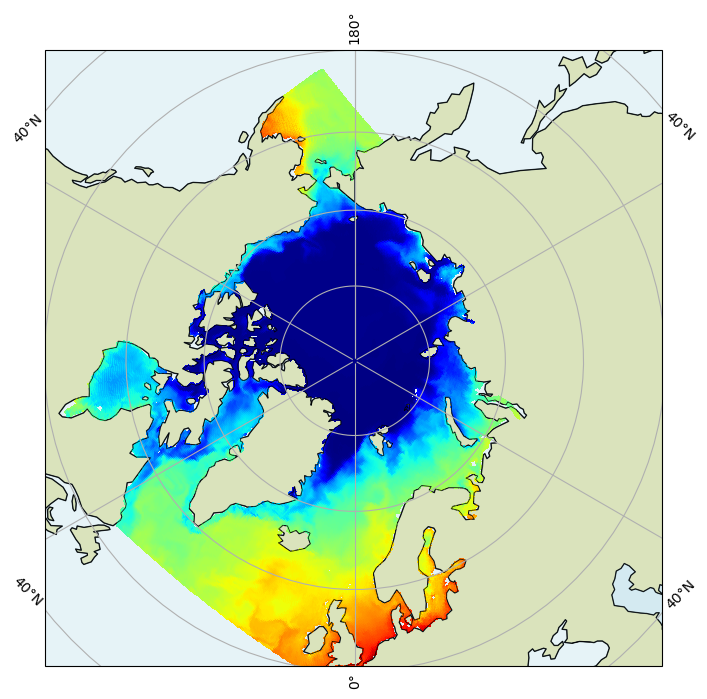

In [9]:
projection = ccrs.NorthPolarStereo()
list_extent = (-180, 180, 50, 90)
plot_field(plon,plat,fld1,list_extent,projection)

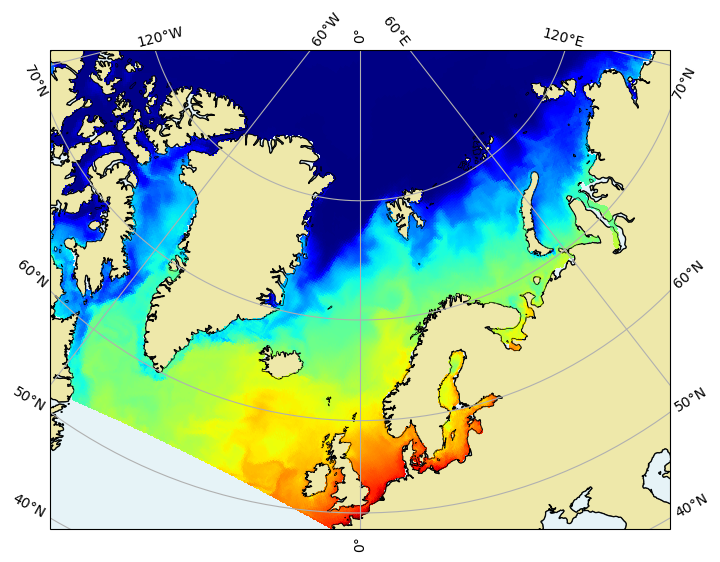

In [10]:
list_extent = (-55, 55, 48, 88)
projection = ccrs.LambertConformal(central_longitude=0, central_latitude=60)
plot_field(plon,plat,fld1,list_extent,projection)

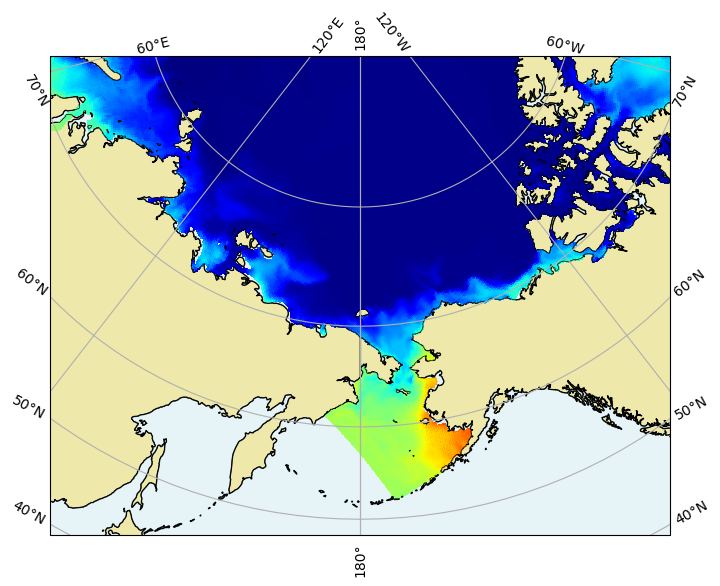

In [11]:
list_extent = (-235, -125, 48, 88)
projection = ccrs.LambertConformal(central_longitude=180, central_latitude=50)
plot_field(plon,plat,fld1,list_extent,projection)